### Importing Libraries

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load Dataset

In [39]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")


### Dataset Overview

In [82]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

1. What's the average customer tenure?
2. What's the highest monthly charge?
3. What's the longest anyone has been a customer?

In [42]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [43]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [44]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Data Dictionary
|   Column     |    Description  |
|--------------|-----------------|
|customerID	   |     Unique customer identifier|
|gender	       |    Customer gender|
|tenure	       |    Number of months with the company|
|Contract	   |   Type of service contract|
|MonthlyCharges |	  Monthly bill amount|
|TotalCharges   |  Total amount charged over customer lifetime|
|Churn	       |  Whether the customer left the company|

In [45]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

### Data Cleaning

In [47]:
df_clean = df.copy()

### Inspect Data Types 
Identify variables that may require conversion before analysis

In [48]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Total Charges is stored as a text because of blank values.

In [49]:
df_clean[df_clean["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Convert TotalCharges to Numeric Data Type

In [51]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [52]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Check for Missing Values
After converting the data type, missing values were identified across all columns.

In [53]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Handle Missing Values

Rows containing missing values in `TotalCharges` were removed because they represented a very small percentage of the dataset and would not significantly impact the analysis.

In [54]:
df_clean = df_clean.dropna()

In [55]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Check for Duplicate Records

 Examined the dataset for duplicate customer records to ensure the accuracy of the analysis.

In [56]:
df_clean.duplicated().sum()

np.int64(0)

In [57]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [58]:
df_clean.shape

(7032, 21)

### Save the Cleaned Dataset

The cleaned dataset was saved as a new CSV file for use in SQL analysis and Power BI dashboard development.

In [59]:
df_clean.to_csv("../data/churn_clean.csv", index=False)

## Data Cleaning Summary

The dataset was reviewed for data quality issues before analysis. The `TotalCharges` column was converted from a text field to a numeric data type after identifying blank string values. These blank values were converted to missing values and removed from the dataset. Duplicate records were checked, and none were found. The cleaned dataset contains 7,032 customer records and is ready for analysis.

### Exploratory Data Analysis

In [60]:
df_clean["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [61]:
df_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [62]:
df_clean["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [63]:
df_clean["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [64]:
df_clean["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

Customer Churn Counts
Churn
No     5174
Yes    1869
Name: count, dtype: int64


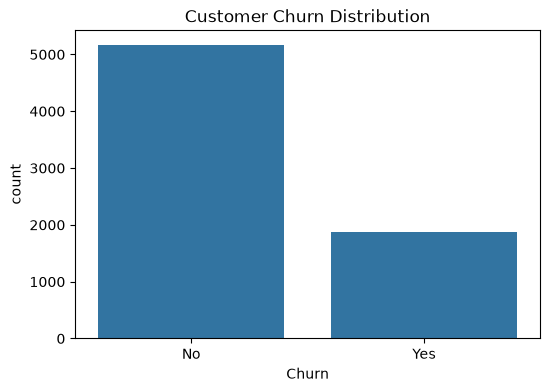

In [65]:
print("Customer Churn Counts")
print(df['Churn'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_clean)
plt.title("Customer Churn Distribution")
plt.show()

#### Observation

Approximately **26.6%** of customers in the dataset have churned, while **73.4%** remain active.

This indicates that customer churn is a significant business issue and warrants further investigation.

In [66]:
df_clean["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

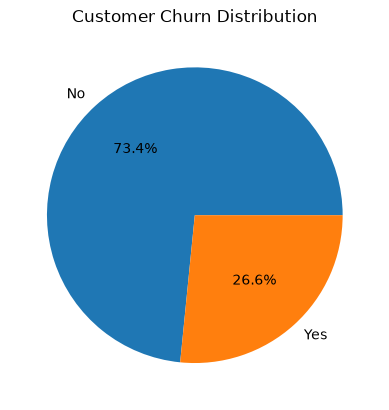

In [67]:
df_clean['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()


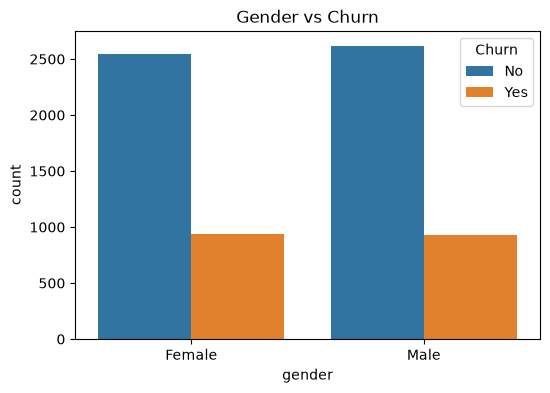

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df_clean)
plt.title("Gender vs Churn")
plt.show()

## Initial Business Questions
1. Which contract type has the highest churn rate?
2. Does internet service type influence churn?
3. Which payment methods are associated with the highest churn?
4. Are customers with higher monthly charges more likely to churn?
5. Does customer tenure affect churn?


### Business Insight
#### Customers with month-to-month contracts have the highest churn rate, while customers with one-year and two-year contracts are more likely to remain with the company. This suggests that long-term contracts improve customer retention by increasing customer commitment and reducing the likelihood of switching providers. 


In [81]:
pd.crosstab(df["Contract"], df_clean["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


<Axes: xlabel='Contract', ylabel='count'>

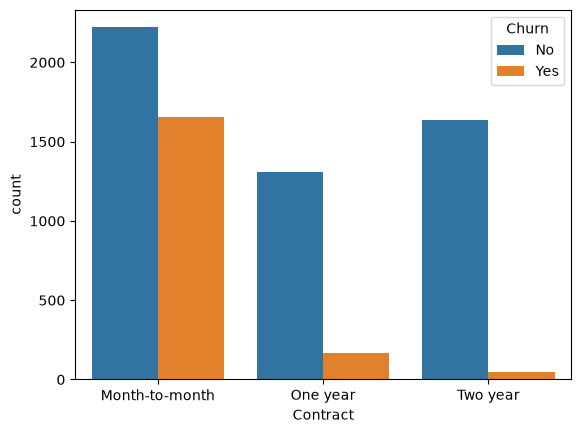

In [70]:
sns.countplot(x='Contract', hue='Churn', data=df_clean)

### Business Recommendation
#### Consider encouraging customers to transition from month-to-month contracts to longer-term contracts by offering incentives such as discounted start up fee's or pricing, loyalty rewards, or bundled services.

### Business Insight
#### Customers using Fiber Optic Internet experience the highest churn rate compared to customers using DSL or those without internet service. Although Fiber Optic is a premium internet service, they are more likely to discontinue their service.

In [79]:
pd.crosstab(df_clean["InternetService"], df_clean["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


<Axes: xlabel='InternetService', ylabel='count'>

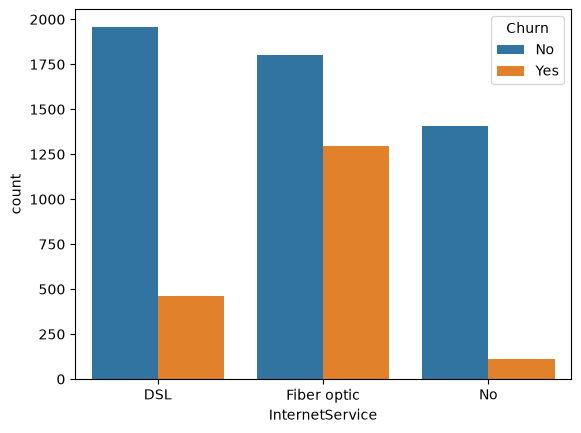

In [72]:
sns.countplot(x='InternetService', hue='Churn', data=df_clean)

### Business Recommendation
#### Further investigate potential cases of churn among Fiber Optic customers, such as pricing, service reliability, or customer support. Start targeted retention intiatives for fiber customers to help reduce overall churn.

### Business Insight
#### Customers who pay using Electronic Check have the highest churn rate among all payment methods. Customers using automatic payment methods, such as bank transfers or credit cards, remain with the company longer.

In [73]:
pd.crosstab(df_clean["PaymentMethod"], df_clean["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


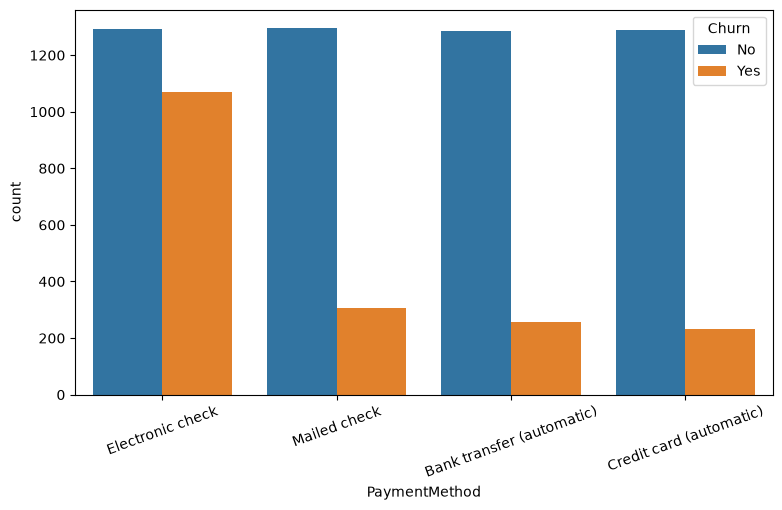

In [74]:
plt.figure(figsize=(9,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df_clean)
plt.xticks(rotation=20)
plt.show()

### Business Recommendation
#### Encourage customers to enroll in automatic payment options by offering incentives or simplifying the enrollment process. Automatic payments may improve customer rentention.

### Business Insight
#### Customers who churned paid an average monthly charge of $74, compared to $61 for customers who remained wih the company. This suggests that customers withs higher monthly charges are more likely to leave the company, also indicating that pricing or percevied value may influence customer retention.


In [75]:
df_clean.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

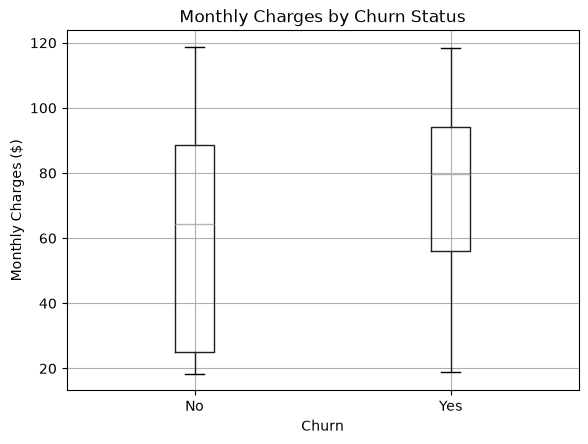

In [76]:
df_clean.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")  # Removes the default title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()

In [77]:
df_clean.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

### Business Recommendation
#### Consider reviewing pricing strategies for higher-cost plans and offering loyalty discounts, personlaized promotions, or additional service benefits to customers with higher monthly charges.

### Summary
#### The analysis identified several key drivers of customer churn. Customers on month-to-month contracts, those with shorter tenures, customers paying higher monthly charges, fiber optic internet users, and customers using electronic checks exhibited the highest likelihood of churning. These findings suggest that pricing, contract commitment, customer experience, and payment preferences all contribute to customer retention. To reduce churn, the company should prioritize converting customers to longer-term contracts, improving early customer engagement, reviewing pricing strategies for premium services, and encouraging enrollment in automatic payment methods.